<a href="https://colab.research.google.com/github/NatanaelAnantaSatrio/SistemRekomendasi/blob/main/Praktikum2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


**EXPLORATORY DATASET**


**Movies Dataset**

In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SistemRekomendasi/movie.csv")

In [ ]:
print("Jumlah Data :", len(df1.iloc[:,1]))
print("Jumlah Fitur :", len(df1.iloc[1,:]))
print(f"Terdapat {len(df1.iloc[:,1])} Kolom Fitur pada Dataset yaitu:")
print("Fitur Data :", df1.columns.tolist()[:])
pd.options.display.max_columns = None
df1.head()

Jumlah Data : 27278
Jumlah Fitur : 3
Terdapat 27278 Kolom Fitur pada Dataset yaitu:
Fitur Data : ['movieId', 'title', 'genres']


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


In [ ]:
import re

def clean_title(title):
    return re.sub("[^a-zA-Z0-9 ]", "", title)

In [ ]:
# Pisahkan genre menggunakan pemisah '|'
df1['genres'] = df1['genres'].str.split('|')

# Bersihkan judul film
df1['title'] = df1['title'].apply(clean_title)

# Perbarui movies_data
movies_data = df1[['movieId', 'title', 'genres']]

# Mendapatkan genre unik dari semua film
unique_genres = pd.Series([genre for genres_list in movies_data['genres'] for genre in genres_list]).unique()

# Output hasil
print(movies_data.head())

   movieId                             title  \
0        1                    Toy Story 1995   
1        2                      Jumanji 1995   
2        3             Grumpier Old Men 1995   
3        4            Waiting to Exhale 1995   
4        5  Father of the Bride Part II 1995   

                                              genres  
0  [Adventure, Animation, Children, Comedy, Fantasy]  
1                     [Adventure, Children, Fantasy]  
2                                  [Comedy, Romance]  
3                           [Comedy, Drama, Romance]  
4                                           [Comedy]  


In [ ]:
print(f"Terdapat {movies_data['title'].nunique()} Judul Film")
print(f"Terdapat {len(unique_genres)} Genre Film.")
print("Genre Film:", unique_genres)

Terdapat 27261 Judul Film
Terdapat 20 Genre Film.
Genre Film: ['Adventure' 'Animation' 'Children' 'Comedy' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Mystery' 'Sci-Fi' 'IMAX'
 'Documentary' 'War' 'Musical' 'Western' 'Film-Noir' '(no genres listed)']


In [ ]:
# Periksa jumlah baris dengan '(no genres listed)'
no_genres_count = movies_data[movies_data['genres'].apply(lambda x: '(no genres listed)' in x)].shape[0]
print(f"Terdapat {no_genres_count} film tanpa genre.")

# Hapus baris dengan '(no genres listed)'
movies_data = movies_data[~movies_data['genres'].apply(lambda x: '(no genres listed)' in x)]

# Perbarui daftar genre unik
unique_genres = pd.Series([genre for genres_list in movies_data['genres'] for genre in genres_list]).unique()

# Tampilkan hasil setelah penghapusan
print(f"Setelah penghapusan, terdapat {movies_data['title'].nunique()} Judul Film.")
print(f"Terdapat {len(unique_genres)} Genre Film setelah pembaruan.")
print("Genre Film:", unique_genres)

Terdapat 246 film tanpa genre.
Setelah penghapusan, terdapat 27015 Judul Film.
Terdapat 19 Genre Film setelah pembaruan.
Genre Film: ['Adventure' 'Animation' 'Children' 'Comedy' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Mystery' 'Sci-Fi' 'IMAX'
 'Documentary' 'War' 'Musical' 'Western' 'Film-Noir']


**Visualisasi Dataset**

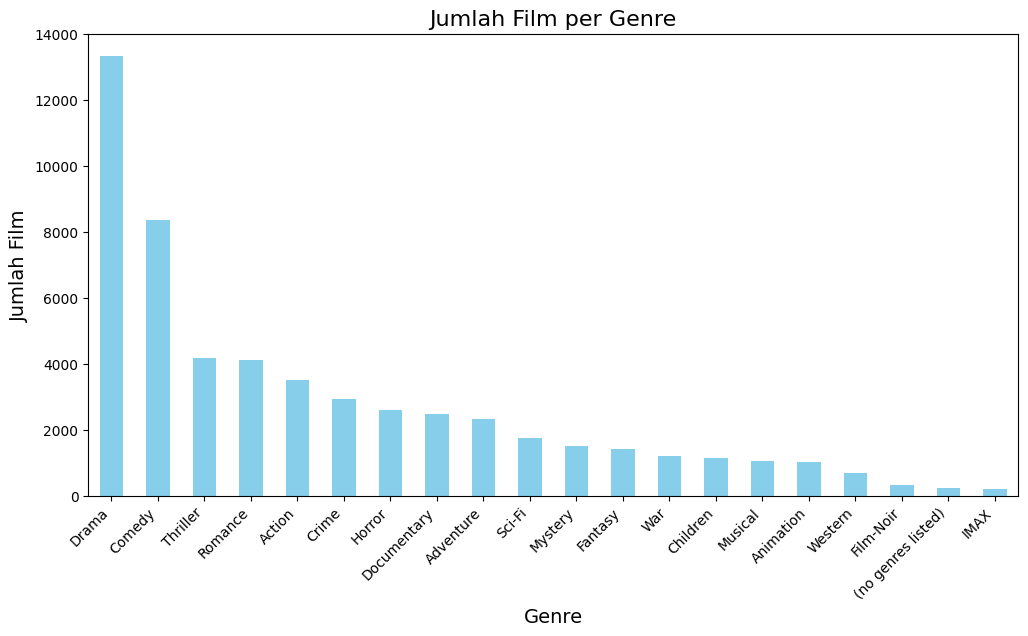

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Menghitung jumlah film per genre
genre_counts = pd.Series([genre for genres_list in movies_data['genres'] for genre in genres_list]).value_counts()

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Jumlah Film per Genre', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Jumlah Film', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

Ratings Dataset

In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SistemRekomendasi/rating.csv")

In [ ]:
print("Jumlah Data :", len(df2.iloc[:,1]))
print("Jumlah Fitur :", len(df2.iloc[1,:]))
print(f"Terdapat {len(df2.iloc[:,1])} Kolom Fitur pada Dataset yaitu:")
print("Fitur Data :", df2.columns.tolist()[:])
pd.options.display.max_columns = None
df2.head()

Jumlah Data : 20000263
Jumlah Fitur : 4
Terdapat 20000263 Kolom Fitur pada Dataset yaitu:
Fitur Data : ['userId', 'movieId', 'rating', 'timestamp']


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [ ]:
# Drop timestamp column
ratings_data = df2.drop(['timestamp'], axis=1)
print(ratings_data.head())

   userId  movieId  rating
0       1        2     3.5
1       1       29     3.5
2       1       32     3.5
3       1       47     3.5
4       1       50     3.5


In [ ]:
# Melihat Missing Values
print("Jumlah Missing Values per Kolom:")
print(df2.isnull().sum())

print("\nJumlah Data Duplicates:")
print(df2.duplicated().sum())

Jumlah Missing Values per Kolom:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Jumlah Data Duplicates:
0


In [ ]:
ratings_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
dtypes: float64(1), int64(2)
memory usage: 457.8 MB


In [ ]:
print("Distribusi Rating:")
print(df2['rating'].value_counts())

print("\nRating Rata-Rata per Film:")
print(df2.groupby('movieId')['rating'].mean().head())

print("\nRating Rata-Rata per Pengguna:")
print(df2.groupby('userId')['rating'].mean().head())

Distribusi Rating:
rating
4.0    5561926
3.0    4291193
5.0    2898660
3.5    2200156
4.5    1534824
2.0    1430997
2.5     883398
1.0     680732
1.5     279252
0.5     239125
Name: count, dtype: int64

Rating Rata-Rata per Film:
movieId
1    3.921240
2    3.211977
3    3.151040
4    2.861393
5    3.064592
Name: rating, dtype: float64

Rating Rata-Rata per Pengguna:
userId
1    3.742857
2    4.000000
3    4.122995
4    3.571429
5    4.272727
Name: rating, dtype: float64


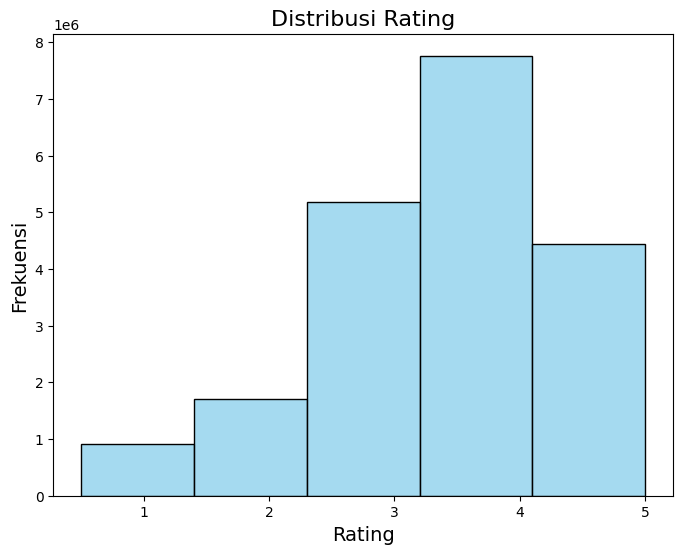

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df2['rating'], bins=5, kde=False, color='skyblue')
plt.title('Distribusi Rating', fontsize=16)
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Frekuensi', fontsize=14)
plt.show()

**MERGE 2 DATAFRAMES**

In [ ]:
combined_data = ratings_data.merge(movies_data, on='movieId')
print(combined_data.head())

   userId  movieId  rating                                              title  \
0       1        2     3.5                                       Jumanji 1995   
1       1       29     3.5  City of Lost Children The Cit des enfants perd...   
2       1       32     3.5                 Twelve Monkeys aka 12 Monkeys 1995   
3       1       47     3.5                               Seven aka Se7en 1995   
4       1       50     3.5                            Usual Suspects The 1995   

                                         genres  
0                [Adventure, Children, Fantasy]  
1  [Adventure, Drama, Fantasy, Mystery, Sci-Fi]  
2                   [Mystery, Sci-Fi, Thriller]  
3                           [Mystery, Thriller]  
4                    [Crime, Mystery, Thriller]  


In [ ]:
# Rating Rata-Rata per Film
avg_ratings_per_movie = combined_data.groupby('title')['rating'].mean().sort_values(ascending=False)
print("Top 10 Film dengan Rata-Rata Rating Tertinggi:")
print(avg_ratings_per_movie.head(10))

Top 10 Film dengan Rata-Rata Rating Tertinggi:
title
Barchester Chronicles The 1982                        5.0
Flight of the Conchords A Texan Odyssey 2006          5.0
Argentina latente 2007                                5.0
Central Park 1991                                     5.0
Marihuana 1936                                        5.0
Palestine Is Still the Issue 2003                     5.0
Welcome to Australia 1999                             5.0
Oranges 2004                                          5.0
Paying the Price Killing the Children of Iraq 2000    5.0
Lady of Chance A 1928                                 5.0
Name: rating, dtype: float64


In [ ]:
movie_rating_counts = combined_data.groupby('title')['rating'].count().sort_values(ascending=False)
print("Top 10 Film dengan Jumlah Rating Terbanyak:")
print(movie_rating_counts.head(10))

Top 10 Film dengan Jumlah Rating Terbanyak:
title
Pulp Fiction 1994                        67310
Forrest Gump 1994                        66172
Shawshank Redemption The 1994            63366
Silence of the Lambs The 1991            63299
Jurassic Park 1993                       59715
Star Wars Episode IV  A New Hope 1977    54502
Braveheart 1995                          53769
Terminator 2 Judgment Day 1991           52244
Matrix The 1999                          51334
Schindlers List 1993                     50054
Name: rating, dtype: int64


In [ ]:
# Memisahkan Genre
exploded_data = combined_data.explode('genres')

# Menghitung Jumlah Pengguna yang Memberi Rating pada Tiap Genre
users_per_genre = exploded_data.groupby('genres')['userId'].nunique()

# Rata Rata Rating di Tiap Genre
avg_rating_per_genre = exploded_data.groupby('genres')['rating'].mean()

# Cari 3 film terbaik berdasarkan rating rata-rata di tiap genre
top_movies_per_genre = (
    exploded_data.groupby(['genres', 'title'])['rating']
    .mean()
    .reset_index()
    .sort_values(['genres', 'rating'], ascending=[True, False])
    .groupby('genres')
    .head(3)
)

print("Jumlah Pengguna yang Memberi Rating pada Tiap Genre:")
print(users_per_genre)
print("\nRata-Rata Rating per Genre:")
print(avg_rating_per_genre)
print("\n3 Film Terbaik di Tiap Genre:")
print(top_movies_per_genre)

untuk kode # Memisahkan Genre tidak bisa dijalankan karena data yang diolah terlalu banyak sehingga ram pada device jadi crash pada menjalankan kode

In [ ]:
# TAMBAHAN (WAJIB biar tidak crash)
combined_data = combined_data.sample(100000, random_state=42)

# Memisahkan Genre
exploded_data = combined_data.explode('genres')

# Menghitung Jumlah Pengguna yang Memberi Rating pada Tiap Genre
users_per_genre = exploded_data.groupby('genres')['userId'].nunique()

# Rata Rata Rating di Tiap Genre
avg_rating_per_genre = exploded_data.groupby('genres')['rating'].mean()

# Cari 3 film terbaik berdasarkan rating rata-rata di tiap genre
top_movies_per_genre = (
    exploded_data.groupby(['genres', 'title'])['rating']
    .mean()
    .reset_index()
    .sort_values(['genres', 'rating'], ascending=[True, False])
    .groupby('genres')
    .head(3)
)

print("Jumlah Pengguna yang Memberi Rating pada Tiap Genre:")
print(users_per_genre)
print("\nRata-Rata Rating per Genre:")
print(avg_rating_per_genre)
print("\n3 Film Terbaik di Tiap Genre:")
print(top_movies_per_genre)

Jumlah Pengguna yang Memberi Rating pada Tiap Genre:
genres
Action         21537
Adventure      18064
Animation       5263
Children        7574
Comedy         26371
Crime          13909
Documentary     1113
Drama          29878
Fantasy         9459
Film-Noir       1078
Horror          6314
IMAX            2370
Musical         4088
Mystery         7225
Romance        15580
Sci-Fi         13314
Thriller       20766
War             4872
Western         2016
Name: userId, dtype: int64

Rata-Rata Rating per Genre:
genres
Action         3.438391
Adventure      3.506507
Animation      3.632822
Children       3.422410
Comedy         3.415572
Crime          3.655535
Documentary    3.753138
Drama          3.670630
Fantasy        3.515026
Film-Noir      3.941124
Horror         3.244809
IMAX           3.672929
Musical        3.548893
Mystery        3.661589
Romance        3.515179
Sci-Fi         3.436519
Thriller       3.495636
War            3.798905
Western        3.577492
Name: rating, dtype: f

**PEMBUATAN MODEL TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer_title = TfidfVectorizer(ngram_range=(1,2))
tfidf_title = vectorizer_title.fit_transform(movies_data['title'])

In [ ]:
def search_by_title(title):
    title = clean_title(title)
    query_vec = vectorizer_title.transform([title])
    similarity = cosine_similarity(query_vec, tfidf_title).flatten()
    indices = np.argpartition(similarity, -5)[-5:]
    results = movies_data.iloc[indices].iloc[::-1]
    return results

movie_results = search_by_title("Interstellar")
print(movie_results)

       movieId                                    title            genres
22919   109487                        Interstellar 2014    [Sci-Fi, IMAX]
9003     26712                               35 Up 1991     [Documentary]
9004     26713  Days of Being Wild A Fei jingjyuhn 1990  [Drama, Romance]
9005     26714                   Across the Tracks 1991           [Drama]
9006     26717                            Begotten 1990   [Drama, Horror]


**Menggunakan TF_IDF untuk mencari 5 movies dengan judul yang mirip**

In [ ]:
def search_by_title(title):
    title = clean_title(title)
    query_vec = vectorizer_title.transform([title])
    similarity = cosine_similarity(query_vec, tfidf_title).flatten()
    indices = np.argpartition(similarity, -5)[-5:]
    results = movies_data.iloc[indices].iloc[::-1]
    return results

movie_results = search_by_title("Fast and Furious")
print(movie_results)

       movieId                                             title  \
13623    67923     Fast  Furious Fast and the Furious 4 The 2009   
21039   102716   Fast  Furious 6 Fast and the Furious 6 The 2013   
6277      6383  2 Fast 2 Furious Fast and the Furious 2 The 2003   
4274      4369                     Fast and the Furious The 2001   
13954    69945                     Fast and the Furious The 1955   

                                 genres  
13623  [Action, Crime, Drama, Thriller]  
21039   [Action, Crime, Thriller, IMAX]  
6277          [Action, Crime, Thriller]  
4274          [Action, Crime, Thriller]  
13954                  [Crime, Mystery]  


**Mencari movies dengan genre yang mirip**

In [ ]:
vectorizer_genres = TfidfVectorizer(ngram_range=(1,2))

# Gabungkan genre list menjadi string
movies_data['genres_text'] = movies_data['genres'].apply(lambda x: ' '.join(x))

tfidf_genres = vectorizer_genres.fit_transform(movies_data['genres_text'])

def search_similar_genres(genres):
    query_vec = vectorizer_genres.transform([genres])
    similarity = cosine_similarity(query_vec, tfidf_genres).flatten()
    indices = np.argpartition(similarity, -10)[-10:]
    results = movies_data.iloc[indices].iloc[::-1]
    return results

gen = "Adventure Action"
print(search_similar_genres(gen))

       movieId                                      title       genres  \
25089   118446             Journey Beyond Three Seas 1957  [Adventure]   
5868      5967                    Legend of the Lost 1957  [Adventure]   
5765      5864                    Tarzan the Ape Man 1981  [Adventure]   
5746      5845  Pursuit of DB Cooper The aka Pursuit 1981  [Adventure]   
14430    72276  Indian Tomb The Das indische Grabmal 1959  [Adventure]   
14086    70703    Christopher Columbus The Discovery 1992  [Adventure]   
24981   117903                             Dirigible 1931  [Adventure]   
24852   117460           Treasure of the Four Crowns 1983  [Adventure]   
1050      1070                                 Macao 1952  [Adventure]   
924        941                     Mark of Zorro The 1940  [Adventure]   

      genres_text  
25089   Adventure  
5868    Adventure  
5765    Adventure  
5746    Adventure  
14430   Adventure  
14086   Adventure  
24981   Adventure  
24852   Adventure  
1050 

**CALCULATE SCORE**

In [ ]:
def scores_calculator(movie_id):

    # Filter data untuk pengguna serupa
    similar_users = combined_data.loc[
        (combined_data['movieId'] == movie_id) & (combined_data['rating'] >= 4),
        'userId'
    ].unique()

    # Dapatkan rekomendasi berdasarkan pengguna serupa
    similar_user_recs = combined_data.loc[
        (combined_data['userId'].isin(similar_users)) & (combined_data['rating'] >= 4),
        'movieId'
    ].value_counts(normalize=True)

    # Dapatkan rekomendasi berdasarkan semua pengguna
    all_user_recs = combined_data.loc[
        (combined_data['movieId'].isin(similar_user_recs.index)) & (combined_data['rating'] >= 4),
        'movieId'
    ].value_counts(normalize=True)

    # Filter dengan data film yang dipilih
    selected_genres = combined_data.loc[combined_data['movieId'] == movie_id, 'genres'].iloc[0]
    if isinstance(selected_genres, list):
        selected_genres = " ".join(selected_genres)

    # Cari film dengan genre serupa
    movies_with_similar_genres = search_similar_genres(selected_genres)
    similar_genre_ids = movies_with_similar_genres['movieId']

    # Kalikan skor berdasarkan genre serupa
    similar_user_recs.loc[similar_user_recs.index.isin(similar_genre_ids)] *= 1.5
    all_user_recs.loc[all_user_recs.index.isin(similar_genre_ids)] *= 0.9

    # Gabungkan skor dan hitung peringkat
    scores = pd.DataFrame({
        'similar': similar_user_recs,
        'all': all_user_recs
    }).fillna(0)

    # Hindari pembagian nol
    scores['score'] = np.where(scores['all'] > 0, scores['similar'] / scores['all'], 0)

    # Urutkan berdasarkan skor tertinggi
    return scores.sort_values('score', ascending=False)

scores_calculator(3114)

,similar,all,score
movieId,,,
3114,0.790076,0.027189,29.058524
5287,0.007634,0.000876,8.717557
5373,0.007634,0.000876,8.717557
4846,0.007634,0.001313,5.811705
60943,0.007634,0.001313,5.811705
...,...,...,...
1240,0.007634,0.051226,0.149018
590,0.007634,0.054291,0.140606
1270,0.007634,0.058669,0.130113


**RECOMMENDATION RESULT**

In [ ]:
def recommendation_results(user_input, title=0):
    user_input = clean_title(user_input)
    title_candidates = search_by_title(user_input)
    movie_id = title_candidates.iloc[title]['movieId']
    scores = scores_calculator(movie_id)
    results = scores.head(10).merge(movies_data, left_index=True, right_on='movieId')[['title', 'score', 'genres']]
    results.rename(columns={'title': 'title', 'genres': 'genres'}, inplace=True)
    return results

user_input = "Interstellar"
print("Here a similar movies :")
for i in range(5):
    print(i, ": ", search_by_title(user_input)['title'].iloc[i])

title = 0
print("Recommendation_results :")
print(recommendation_results(user_input))

Here a similar movies :
0 :  Interstellar 2014
1 :  35 Up 1991
2 :  Days of Being Wild A Fei jingjyuhn 1990
3 :  Across the Tracks 1991
4 :  Begotten 1990
Recommendation_results :
                                                   title      score  \
22919                                  Interstellar 2014  58.245614   
11739             TMNT Teenage Mutant Ninja Turtles 2007  34.947368   
16267                       Alone in the Wilderness 2004  34.947368   
1383                                          Evita 1996   3.177033   
2660                         Little Shop of Horrors 1986   1.747368   
263                             Legends of the Fall 1994   0.896086   
2543        Star Wars Episode I  The Phantom Menace 1999   0.659384   
1125             Wallace  Gromit The Wrong Trousers 1993   0.546053   
2206                            Edward Scissorhands 1990   0.416040   
1173   Raiders of the Lost Ark Indiana Jones and the ...   0.192019   

                                      